# Pilot city finance profile — oef / br-city-finance-feasibility, release v1

Builds the city side of the Brazil finance-feasibility model for the 50 pilot cities: identity and locode, CAPAG fiscal signal with the versioned credit screen, and the MUNIC finance-push components. Method and holdings: `../..​/methodology.md`. Inputs are the committed extracts of the source reviews (see Traceability in review.md). Output: `data/br_city_finance_profile_pilot.csv`, one row per pilot city.

In [1]:
# Parameters
PILOTS_JSON = "sample/pilotcities.json"
CAPAG_CSV = "../../../../br-stn/br-capag/releases/2026-06-01/data/br_capag_municipios_clean.csv"
FINANCE_PUSH_CSV = "../../../../br-ibge/br-munic/releases/2020-2021/data/br_munic_finance_push.csv"
OUT_CSV = "data/br_city_finance_profile_pilot.csv"
N_PILOTS = 50

import pandas as pd, json, unicodedata, re
print("expecting", N_PILOTS, "pilot cities")

expecting 50 pilot cities


## Load raw

The pilot list is a CityCatalyst export (city id, name, locode, state). The two city-signal inputs are the committed, already-validated extracts of their source reviews; nothing is re-derived from raw sources here.

In [2]:
# Load raw: pilot city list
pilots = pd.DataFrame(json.load(open(PILOTS_JSON))["data"])
pilots.shape

(50, 6)

In [3]:
# Load raw: CAPAG clean extract (fiscal signal + versioned credit screen)
capag = pd.read_csv(CAPAG_CSV, dtype=str)
capag.shape

(5568, 19)

In [4]:
# Load raw: MUNIC finance-push component table
fpush = pd.read_csv(FINANCE_PUSH_CSV, dtype=str)
fpush.shape

(5570, 22)

## Map pilot cities to IBGE codes

The pilot export carries no IBGE code, so the join key is built by matching normalised name plus state against the MUNIC identity columns. Normalisation strips accents and apostrophes on both sides (the MUNIC 2020 base already strips apostrophes from names). Altamira arrives with a null state and matches on name alone; it is nationally unique.

In [5]:
# Clean: normalise names and map state names to UF siglas
def norm(s):
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9 ]", "", s.lower()).strip()

STATE_UF = {"Acre": "AC", "Alagoas": "AL", "Amazonas": "AM", "Bahia": "BA", "Ceará": "CE",
    "Espírito Santo": "ES", "Goiás": "GO", "Mato Grosso": "MT", "Mato Grosso do Sul": "MS",
    "Minas Gerais": "MG", "Pará": "PA", "Paraíba": "PB", "Paraná": "PR", "Pernambuco": "PE",
    "Rio de Janeiro": "RJ", "Rio Grande do Norte": "RN", "Rio Grande do Sul": "RS",
    "Rondônia": "RO", "Roraima": "RR", "São Paulo": "SP", "Sergipe": "SE"}
pilots["uf"] = pilots["region"].map(STATE_UF)
pilots["name_norm"] = pilots["name"].map(norm)
fpush["name_norm"] = fpush["mun_name"].map(norm)
pilots[["name", "region", "uf", "name_norm"]].head(3)

,name,region,uf,name_norm
0,Caxias do Sul,Rio Grande do Sul,RS,caxias do sul
1,Maranguape,Ceará,CE,maranguape
2,Corumbá,Mato Grosso do Sul,MS,corumba


In [6]:
# Map: unique (name, UF) match into the MUNIC identity table
def match_cod_mun(p):
    cand = fpush[fpush["name_norm"] == p["name_norm"]]
    if pd.notna(p["uf"]):
        cand = cand[cand["uf"] == p["uf"]]
    assert len(cand) == 1, (p["name"], p["uf"], len(cand))
    return cand["cod_mun"].iloc[0]

pilots["cod_mun"] = pilots.apply(match_cod_mun, axis=1)
assert pilots["cod_mun"].is_unique
pilots[["name", "locode", "cod_mun"]].head(5)

,name,locode,cod_mun
0,Caxias do Sul,BR CXL,4305108
1,Maranguape,BR MGE,2307700
2,Corumbá,BR CMG,5003207
3,Altamira,BR ATM,1500602
4,Campo Grande,BR CGR,5002704


## Join the city signals

In [7]:
# Join: finance-push components (all status columns kept, transparency over compactness)
FP_COLS = [c for c in fpush.columns if c.endswith("_status") or c in
           ("planning_instrument_count", "climate_legislation_year", "plano_diretor_year",
            "is_survey_refusal_2020", "pop_band", "region")]
prof = pilots.drop(columns=["name_norm"]).merge(
    fpush[["cod_mun"] + FP_COLS].rename(columns={"region": "macro_region"}),
    on="cod_mun", validate="1:1")
prof.shape

(50, 27)

In [8]:
# Join: CAPAG fiscal signal and the versioned credit screen
prof = prof.merge(
    capag[["municipality_code", "capag", "icf", "credit_screen", "credit_screen_rule",
           "fiscal_base_year", "release_date"]].rename(
        columns={"municipality_code": "cod_mun", "release_date": "capag_release_date"}),
    on="cod_mun", how="left", validate="1:1")
prof[["name", "capag", "icf", "credit_screen"]].head(5)

,name,capag,icf,credit_screen
0,Caxias do Sul,A+,Aicf,credit_screen_pass
1,Maranguape,C,Bicf,credit_screen_fail_fiscal
2,Corumbá,B+,Aicf,credit_screen_pass
3,Altamira,C,Bicf,credit_screen_fail_fiscal
4,Campo Grande,C,Bicf,credit_screen_fail_fiscal


## Score finance-push from the rules dataset

The scoring is data-driven: every point comes from one row of the scoring-rules table, families subtotal, and the bucket table maps the 0-14 total to a named tier. The rules files are the single source of truth shared with external reviewers; this notebook only executes them.

In [9]:
# Derive: finance-push score from data/rules/finance_push_scoring_rules.csv
rules = pd.read_csv("data/rules/finance_push_scoring_rules.csv", dtype=str)
buckets = pd.read_csv("data/rules/finance_push_buckets.csv", dtype=str)

def rule_points(rule, df):
    op, val = rule["condition"].split(" ", 1)
    col = df[rule["source_variable"]]
    hit = pd.to_numeric(col, errors="coerce").ge(float(val)) if op == ">=" else col.eq(val)
    return hit.fillna(False).astype(int) * int(rule["points"])

score_detail = pd.DataFrame({f"{r['family']}::{r['component']}" + ("" if r["condition"].startswith(">=") else f" ({r['condition'].split(' ',1)[1]})"): rule_points(r, prof)
                             for _, r in rules.iterrows()})
family_scores = score_detail.T.groupby(rules.set_index(rules.index)["family"].values).sum().T.add_prefix("score_")
prof = pd.concat([prof, family_scores], axis=1)
prof["finance_push_score"] = score_detail.sum(axis=1).mask(prof["is_survey_refusal_2020"].eq("True")).astype("Int64")

def to_bucket(s):
    if pd.isna(s): return None
    row = buckets[(buckets.score_min.astype(int) <= s) & (s <= buckets.score_max.astype(int))]
    return row["bucket"].iloc[0]
prof["finance_push_bucket"] = prof["finance_push_score"].map(to_bucket)
prof[["finance_push_score", "finance_push_bucket"]].value_counts().sort_index()

finance_push_score  finance_push_bucket
6                   developing              1
7                   established             3
8                   established            11
9                   established            14
10                  extensive               6
11                  extensive              10
12                  extensive               2
13                  extensive               3
Name: count, dtype: int64

In [10]:
# Export: step-1 dataset — the scoring worked through, per city (variables → points → families → total → bucket)
import os
os.makedirs("data", exist_ok=True)
scores_out = pd.concat([prof[["cod_mun", "locode", "name", "uf"]], score_detail,
                        family_scores, prof[["finance_push_score", "finance_push_bucket"]]], axis=1)
scores_out.to_csv("data/br_city_finance_push_scores_pilot.csv", index=False)
print("data/br_city_finance_push_scores_pilot.csv", scores_out.shape)

data/br_city_finance_push_scores_pilot.csv (50, 25)


## Validate

In [11]:
# Validate: coverage, keys, and known pilot-list quirks as named exceptions
assert len(prof) == N_PILOTS
assert prof["cod_mun"].is_unique and prof["locode"].is_unique
assert prof["capag"].notna().all(), "every pilot should carry a CAPAG record"
assert prof["env_body_status"].notna().all()
# Named exception: Altamira arrives with null country/region in the pilot export; matched to 1500602 (PA) by unique name.
assert prof.loc[prof["name"].eq("Altamira"), "cod_mun"].eq("1500602").all()
# Named exception: the pilot list's Cruzeiro do Sul is the Rio Grande do Sul municipality (area 155 km2), not the larger Acre namesake.
assert prof.loc[prof["name"].eq("Cruzeiro do Sul"), "uf"].eq("RS").all()
# No 2020 survey refusals among the pilots, so every finance-push component is a real answer.
assert prof["is_survey_refusal_2020"].eq("False").all()
print("all validations passed")

all validations passed


## Export

In [12]:
import os
os.makedirs("data", exist_ok=True)
out = prof.drop(columns=["name_norm"], errors="ignore")
out.to_csv(OUT_CSV, index=False)
print(OUT_CSV, out.shape)

data/br_city_finance_profile_pilot.csv (50, 40)


## Visualise and fit

The two questions the pilot needs answered first: where does the credit gate fall, and how does finance-push capacity spread across the pilots?

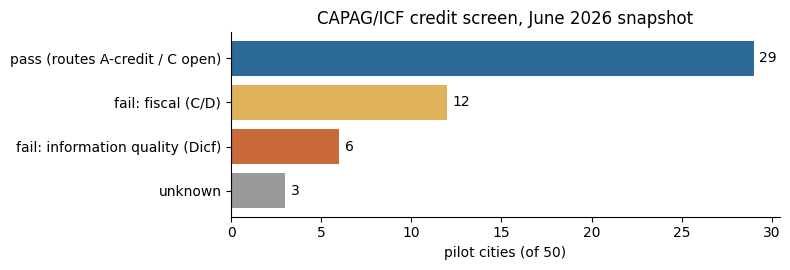

In [13]:
# Chart: the CAPAG credit gate across the 50 pilots
import matplotlib.pyplot as plt
order = ["credit_screen_pass", "credit_screen_fail_fiscal", "credit_screen_fail_information_quality", "credit_screen_unknown"]
labels = {"credit_screen_pass": "pass (routes A-credit / C open)", "credit_screen_fail_fiscal": "fail: fiscal (C/D)",
          "credit_screen_fail_information_quality": "fail: information quality (Dicf)", "credit_screen_unknown": "unknown"}
counts = prof["credit_screen"].value_counts().reindex(order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh([labels[k] for k in order][::-1], counts[::-1], color=["#999999", "#c96a3b", "#e0b25c", "#2b6a99"])
for i, v in enumerate(counts[::-1]):
    ax.text(v + 0.3, i, str(v), va="center")
ax.set_xlabel("pilot cities (of 50)")
ax.set_title("CAPAG/ICF credit screen, June 2026 snapshot")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

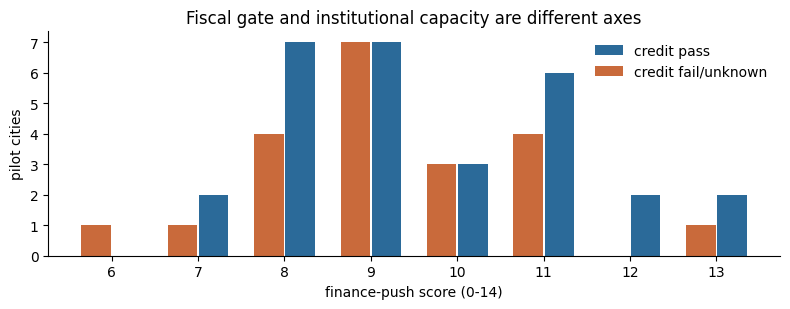

finance_push_score,6,7,8,9,10,11,12,13
credit_screen,,,,,,,,
credit fail/unknown,1,1,4,7,3,4,0,1
credit pass,0,2,7,7,3,6,2,2


In [14]:
# Chart: finance-push core components against the credit gate
gate = prof["credit_screen"].eq("credit_screen_pass").map({True: "credit pass", False: "credit fail/unknown"})
fig, ax = plt.subplots(figsize=(8, 3.2))
for g, color in [("credit pass", "#2b6a99"), ("credit fail/unknown", "#c96a3b")]:
    sub = prof.loc[gate.eq(g), "finance_push_score"].value_counts().sort_index()
    ax.bar(sub.index.astype(int) + (0.18 if g == "credit pass" else -0.18), sub.values, width=0.34, label=g, color=color)
ax.set_xlabel("finance-push score (0-14)")
ax.set_ylabel("pilot cities")
ax.set_title("Fiscal gate and institutional capacity are different axes")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
pd.crosstab(gate, prof["finance_push_score"])

In [15]:
# Fit: the four-quadrant read the methodology's gap ladder starts from
prof["quadrant"] = (
    prof["credit_screen"].eq("credit_screen_pass").map({True: "credit-open", False: "credit-closed"})
    + " / " +
    prof["finance_push_bucket"].isin(["established", "extensive"]).map({True: "push-strong", False: "push-modest"}))
prof.groupby("quadrant")[["name"]].agg(list)

,name
quadrant,
credit-closed / push-modest,[Ilhéus]
credit-closed / push-strong,"[Maranguape, Altamira, Campo Grande, Barcarena..."
credit-open / push-strong,"[Caxias do Sul, Corumbá, Arapiraca, Serra, Rio..."


## Findings

All 50 pilots are scoreable on the starting configuration (CAPAG plus finance-push): no missing CAPAG records, no MUNIC refusals, and the name-based mapping resolved uniquely, including the two quirks asserted above. The credit gate splits the pilots 29 pass to 21 fail-or-unknown, and the crosstab shows the two axes genuinely differ (fiscally gated cities span the full finance-push range), which is the premise of the route-eligibility design. Climate-specific capacity is thin even in this pilot set (14 of 50 with climate legislation), consistent with the national size gradient. The remaining model inputs (intervention sector tags, fund-supply inventory, per-intervention legal verdicts) are absent by status, not by gap in the city profile; see methodology.md for the build order.